In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
class RateCalculations:
    def __init__(self, mass_DM_list, q_list, omega_list):
        c = 2.998e5 #in km/s
        self.mass_DM_list = mass_DM_list
        self.mass_proton = 938.272e3 # keV
        self.density_DM = 0.3e6 # keV/cm^3, plus minus 0.1
        self.density_target = 1.307e30 # keV/cm^3 from silicon density of 2329.6 kg/m3
        self.v_esc = 500/c 
        self.v_earth = 240/c 
        self.v_disp = 220/c
        self.q_list = q_list
        self.omega_list = omega_list
        self.cross_section = 1e-42 # cm^2

    def get_v_min(self):
        '''
        v_min: 3d array shape (num of DM mass, num of p, num of omega)
        '''
        omega_list = self.omega_list[np.newaxis, np.newaxis, :] 
        q_list = self.q_list[np.newaxis, :, np.newaxis]
        mass_DM_list = self.mass_DM_list[:, np.newaxis, np.newaxis]
        self.v_min = omega_list/ q_list + q_list / (2 * mass_DM_list)
    
    def _inverse_mean_sol1(self):
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2)) # 1904.07915 eqn 108
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf((self.v_min+self.v_earth)/self.v_disp) 
                                                       - sp.special.erf((self.v_min-self.v_earth)/self.v_disp))
                        - 4 * self.v_earth * np.exp(-ratio**2))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral 

    def _inverse_mean_sol2(self): 
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf(ratio) 
                                                       - sp.special.erf((self.v_min-self.v_earth)/self.v_disp))
                        - 2 * (self.v_esc-self.v_min+self.v_earth) * np.exp(-ratio**2 ))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral

    def get_inverse_mean_func(self,): # 1509.01598 appendix B
        '''
        returns: inverse mean function, 3d array with the same shape as v_min (num of DM mass, num of p, num of omega)
        '''
        self.get_v_min()
        self.inverse_mean_func = np.where(self.v_min>(self.v_esc+self.v_earth), 0, 
                        np.where(self.v_min<(self.v_esc-self.v_earth),
                                self._inverse_mean_sol1(),
                                self._inverse_mean_sol2()))
    
    def get_scattering_rate(self, s_factor): # 2108.03239 eqn 11
        # eqn for differential rate? 
        '''
        s_factor
        returns: dR/dq. 2d array (num of DM mass, num of p)
        '''
        reducedMass = self.mass_DM_list * self.mass_proton/(self.mass_DM_list + self.mass_proton)
        constFactor = self.density_DM * self.cross_section / (4* np.pi * self.density_target * self.mass_DM_list * reducedMass**2)
        omega_integral = sp.integrate.simpson(self.inverse_mean_func * s_factor, self.omega_list, axis=-1) # integrate over omega
        q_integral = sp.integrate.simpson(omega_integral * self.q_list, self.q_list, axis=-1) # integrate over q
        self.scattering_rate = q_integral * constFactor
    # def _get_omega_integral(self,):
    #     '''
    #     Helper function 
    #     ''' 

    def get_cross_section(self, ):
        return 3/self.scattering_rate # I got this from the 2011_Paper_Scattering.ipynb in this repo dont understand
        


In [3]:
max_q = 300 # keV
qlist = np.linspace(0, max_q,501)[1:] # keV
max_omega = 2500*1e-6 # keV
xlength = 400
omglist = np.linspace(0, max_omega,xlength+1)[1: ]
mass=26161e3 # sillicon, keV
latticeConst= 2*np.pi/2.28 # si, keV^-3
# impulse approx
deltasq = qlist[:, np.newaxis]**2 * 13.13e-6/(2*mass)
sfactor_ia =  28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omglist[np.newaxis, :]-(qlist[:, np.newaxis]**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)


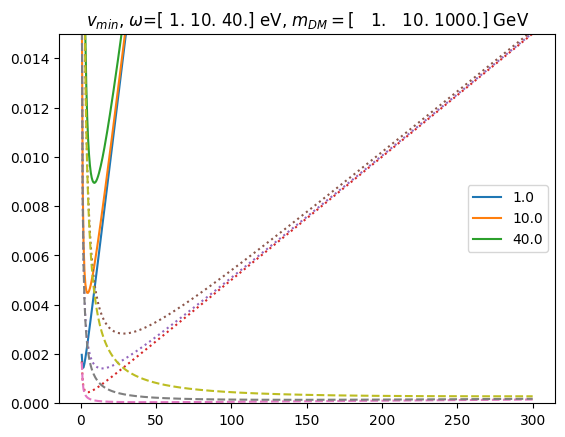

In [4]:
# qlist = np.linspace(0, 75,501)[1:] # 0 ~ 75 keV
massdm = np.array([1000, 1e4, 1e6])
shortomglist = np.array([1e-3, 10e-3, 40e-3])
vmin = shortomglist[np.newaxis, np.newaxis, :] /qlist[np.newaxis, :, np.newaxis] + qlist[np.newaxis, :, np.newaxis]/(2*massdm[:, np.newaxis, np.newaxis])
plt.plot(qlist, vmin[0], label=shortomglist*1e3)
plt.plot(qlist, vmin[1], linestyle=":")
plt.plot(qlist, vmin[2],linestyle="--")
plt.ylim(0,0.015)
plt.title('$v_{min}$, '+f'$\omega$={shortomglist*1e3} eV, '+r'$m_{DM}=$'+f'{massdm*1e-3} '+"GeV" )
plt.legend()

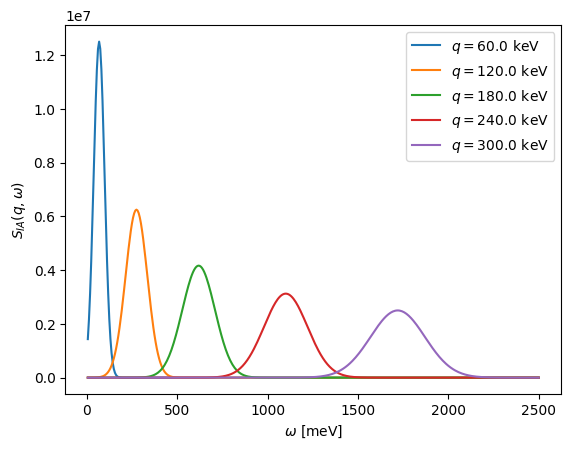

In [5]:
plt.plot(omglist*1e6, sfactor_ia[99],label=f'$q=${qlist[99]} keV')
plt.plot(omglist*1e6, sfactor_ia[199],label=f'$q=${qlist[199]} keV')
plt.plot(omglist*1e6, sfactor_ia[299],label=f'$q=${qlist[299]} keV')
plt.plot(omglist*1e6, sfactor_ia[399],label=f'$q=${qlist[399]} keV')
plt.plot(omglist*1e6, sfactor_ia[499],label=f'$q=${qlist[499]} keV')
plt.xlabel(r"$\omega$ [meV]" )
plt.ylabel(r"$S_{IA}(q, \omega)$")
plt.legend()

In [6]:
dmmasslist = 10**np.linspace(3, 6, 200) #  keV
test = RateCalculations(dmmasslist, qlist, omglist)
test.get_inverse_mean_func()


In [7]:
test.get_scattering_rate(sfactor_ia)

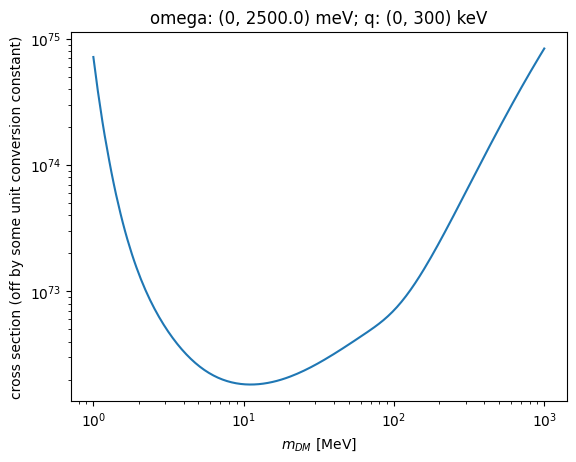

In [9]:
plt.plot(dmmasslist*1e-3, 3/test.scattering_rate)
plt.xlabel(r'$m_{DM}$ [MeV]')
plt.ylabel('cross section (off by some unit conversion constant)')
plt.title(f'omega: (0, {max_omega*1e6}) meV; q: (0, {max_q}) keV')
plt.yscale('log')
plt.xscale('log')